## CREDIT CARD DEFAULT PREDICTION 

### Import Required Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


###  Load Credit Card Dataset

In [2]:
df = pd.read_csv("Credit_Card.csv",sep=";",engine="python")

### Dataset Inspection

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (34788, 30)


In [4]:
display(df.head())


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [5]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']


In [6]:
print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])



Number of rows: 34788
Number of columns: 30


In [7]:
print(df.dtypes)



ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
risk_leak                      object
BILL_AMT_SUM

In [8]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709
dtype: int64


In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 4788


### Missing Values, Duplicates

In [10]:
target = "default.payment.next.month"

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

In [11]:
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_summary)



,Missing_Count,Missing_Percentage
SEX,1767,5.08
AGE,1755,5.04
PAY_AMT2,1744,5.01
EDUCATION,1734,4.98
MARRIAGE,1733,4.98
PAY_AMT1,1725,4.96
LIMIT_BAL,1709,4.91
LIMIT_BAL_LOG,1709,4.91


In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")


Duplicate rows: 4788
Duplicate percentage: 13.76%


### Target distribution

In [13]:
target_counts = df[target].value_counts().sort_index()
target_percentages = df[target].value_counts(
    normalize=True
).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_summary)

print("\nTarget meaning:")
print("0 = No default")
print("1 = Default")

,Count,Percentage
default.payment.next.month,,
0,28132,80.87
1,6656,19.13



Target meaning:
0 = No default
1 = Default


### Duplicate Record Investigation

In [14]:
exact_duplicates = df[df.duplicated(keep=False)].copy()

print("Total rows involved in exact duplicates:", len(exact_duplicates))
print("Unique duplicated rows:", exact_duplicates.drop_duplicates().shape[0])

duplicated_ids = exact_duplicates["ID"].duplicated(keep=False).sum()

print("\nRows with duplicated IDs:", duplicated_ids)
print(
    "Percentage of dataset with duplicated IDs:",
    round((duplicated_ids / len(df)) * 100, 2),
    "%"
)


Total rows involved in exact duplicates: 9063
Unique duplicated rows: 4275

Rows with duplicated IDs: 9063
Percentage of dataset with duplicated IDs: 26.05 %


In [15]:
print("\nSample duplicated records:")
display(
    exact_duplicates
    .sort_values("ID")
    .head(10)
)



Sample duplicated records:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
30833,12,260000.0,2.0,1.0,2.0,51.0,-1,-1,-1,-1,...,8583.0,22301.0,0.0,3640.0,0,-0.11916277091141969,88369.0,12.468.440.756.144.100,City_10,1
31116,12,260000.0,2.0,1.0,2.0,51.0,-1,-1,-1,-1,...,8583.0,22301.0,0.0,3640.0,0,-0.11916277091141969,88369.0,12.468.440.756.144.100,City_10,1
11,12,260000.0,2.0,1.0,2.0,51.0,-1,-1,-1,-1,...,8583.0,22301.0,0.0,3640.0,0,-0.11916277091141969,88369.0,12.468.440.756.144.100,City_10,1
32245,15,250000.0,1.0,1.0,2.0,29.0,0,0,0,0,...,3000.0,3000.0,3000.0,3000.0,0,0.015565897113188685,373591.0,12.429.220.196.836.300,City_26,1
14,15,250000.0,1.0,1.0,2.0,29.0,0,0,0,0,...,3000.0,3000.0,3000.0,3000.0,0,0.015565897113188685,373591.0,12.429.220.196.836.300,City_26,1
17,18,320000.0,1.0,1.0,1.0,49.0,0,0,0,-1,...,75940.0,20000.0,195599.0,50000.0,0,0.03949671469299256,966014.0,12.676.079.399.771.000,City_47,1
32060,18,320000.0,1.0,1.0,1.0,49.0,0,0,0,-1,...,75940.0,20000.0,195599.0,50000.0,0,0.03949671469299256,966014.0,12.676.079.399.771.000,City_47,1
20,21,130000.0,2.0,3.0,2.0,39.0,0,0,0,0,...,1000.0,2000.0,930.0,33764.0,0,0.024878042104237694,123883.0,11.775.297.421.715.800,City_39,1
32612,21,130000.0,2.0,3.0,2.0,39.0,0,0,0,0,...,1000.0,2000.0,930.0,33764.0,0,0.024878042104237694,123883.0,11.775.297.421.715.800,City_39,1
33,34,500000.0,2.0,NaN,1.0,54.0,-2,-2,-2,-2,...,7521.0,71439.0,981.0,51582.0,0,0.07670939441710961,125744.0,13.122.365.377.402.300,City_16,1


In [16]:
target_per_id = (
    df.groupby("ID")[target]
    .nunique()
)

conflicting_ids = target_per_id[target_per_id > 1]

print("\nIDs having different target values:", len(conflicting_ids))

if len(conflicting_ids) > 0:
    print("Warning: Some IDs have conflicting target values.")
else:
    print("No ID has conflicting target values.")


IDs having different target values: 0
No ID has conflicting target values.


### Remove Exact Duplicate Records

In [17]:
df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

removed_rows = len(df) - len(df_clean)

print("Duplicate rows removed:", removed_rows)
print(
    "Percentage of original data removed:",
    round((removed_rows / len(df)) * 100, 2),
    "%"
)

print("\nRemaining duplicate rows:", df_clean.duplicated().sum())


Original dataset shape: (34788, 30)
Cleaned dataset shape: (30000, 30)
Duplicate rows removed: 4788
Percentage of original data removed: 13.76 %

Remaining duplicate rows: 0


### Descriptive Statistics for Key Variables

In [18]:
numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM",
    "LIMIT_BAL_LOG"
]


In [19]:
for col in numeric_features:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )


In [20]:
descriptive_stats = pd.DataFrame({
    "Mean": df_clean[numeric_features].mean(),
    "Median": df_clean[numeric_features].median(),
    "Standard Deviation": df_clean[numeric_features].std()
})

descriptive_stats = descriptive_stats.round(2)
display(descriptive_stats)

,Mean,Median,Standard Deviation
LIMIT_BAL,183123.85,140000.0,232390.94
AGE,35.50,34.0,9.22
BILL_AMT_SUM,294750.69,128032.5,569241.47
LIMIT_BAL_LOG,NaN,NaN,NaN


### Inspect LIMIT_BAL_LOG

In [21]:
print("Data type:", df_clean["LIMIT_BAL_LOG"].dtype)

print("\nSample values:")
display(df_clean["LIMIT_BAL_LOG"].head(20))

print("\nNumber of non-null values:",
      df_clean["LIMIT_BAL_LOG"].notna().sum())

print("Number of missing values:",
      df_clean["LIMIT_BAL_LOG"].isna().sum())

print("\nUnique sample values:")
print(df_clean["LIMIT_BAL_LOG"].dropna().unique()[:20])

Data type: float64

Sample values:


0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: LIMIT_BAL_LOG, dtype: float64


Number of non-null values: 0
Number of missing values: 30000

Unique sample values:
[]


### Complete Missing-Value Profile After Cleaning

In [22]:
missing_profile = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

missing_profile = missing_profile[
    missing_profile["Missing Count"] > 0
].sort_values(
    "Missing Count",
    ascending=False
)
display(missing_profile)

print("\nTotal columns containing missing values:",
      len(missing_profile))

,Missing Count,Missing Percentage
LIMIT_BAL_LOG,30000,100.0
LIMIT_BAL,1500,5.0
EDUCATION,1500,5.0
SEX,1500,5.0
MARRIAGE,1500,5.0
AGE,1500,5.0
PAY_AMT1,1500,5.0
PAY_AMT2,1500,5.0



Total columns containing missing values: 8


### Categorical Variable Distribution


In [23]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]


for col in categorical_features:
    print(f"\n{'-' * 60}")
    print(f"{col}")
    print(f"{'-' * 60}")
    
    print("Number of unique values:", df_clean[col].nunique(dropna=True))
    
    distribution = pd.DataFrame({
        "Count": df_clean[col].value_counts(dropna=False),
        "Percentage": (
            df_clean[col]
            .value_counts(normalize=True, dropna=False) * 100
        ).round(2)
    })
    
    display(distribution)


------------------------------------------------------------
SEX
------------------------------------------------------------
Number of unique values: 2


,Count,Percentage
SEX,,
2.0,17213,57.38
1.0,11287,37.62
NaN,1500,5.00



------------------------------------------------------------
EDUCATION
------------------------------------------------------------
Number of unique values: 7


,Count,Percentage
EDUCATION,,
2.0,13343,44.48
1.0,10031,33.44
3.0,4678,15.59
NaN,1500,5.00
5.0,268,0.89
4.0,117,0.39
6.0,49,0.16
0.0,14,0.05



------------------------------------------------------------
MARRIAGE
------------------------------------------------------------
Number of unique values: 4


,Count,Percentage
MARRIAGE,,
2.0,15141,50.47
1.0,13006,43.35
NaN,1500,5.00
3.0,304,1.01
0.0,49,0.16



------------------------------------------------------------
CITY
------------------------------------------------------------
Number of unique values: 50


,Count,Percentage
CITY,,
City_47,662,2.21
City_15,642,2.14
City_32,635,2.12
City_3,634,2.11
City_25,634,2.11
City_9,631,2.10
City_42,628,2.09
City_17,628,2.09
City_19,623,2.08



------------------------------------------------------------
RISK_RATING
------------------------------------------------------------
Number of unique values: 3


,Count,Percentage
RISK_RATING,,
1,23182,77.27
2,6355,21.18
3,463,1.54


### Target Class Distribution


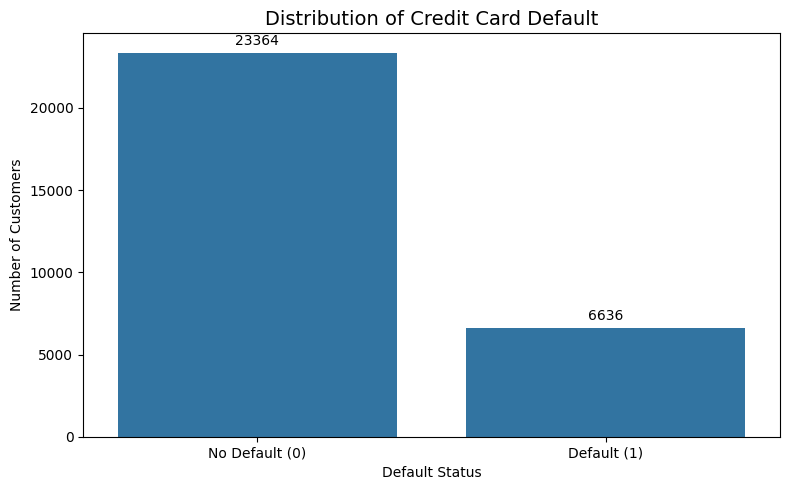

In [24]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_clean,
    x=target
)

plt.title("Distribution of Credit Card Default", fontsize=14)
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.xticks(
    [0, 1],
    ["No Default (0)", "Default (1)"]
)

plt.tight_layout()
plt.show()

###  Numerical Feature Distributions

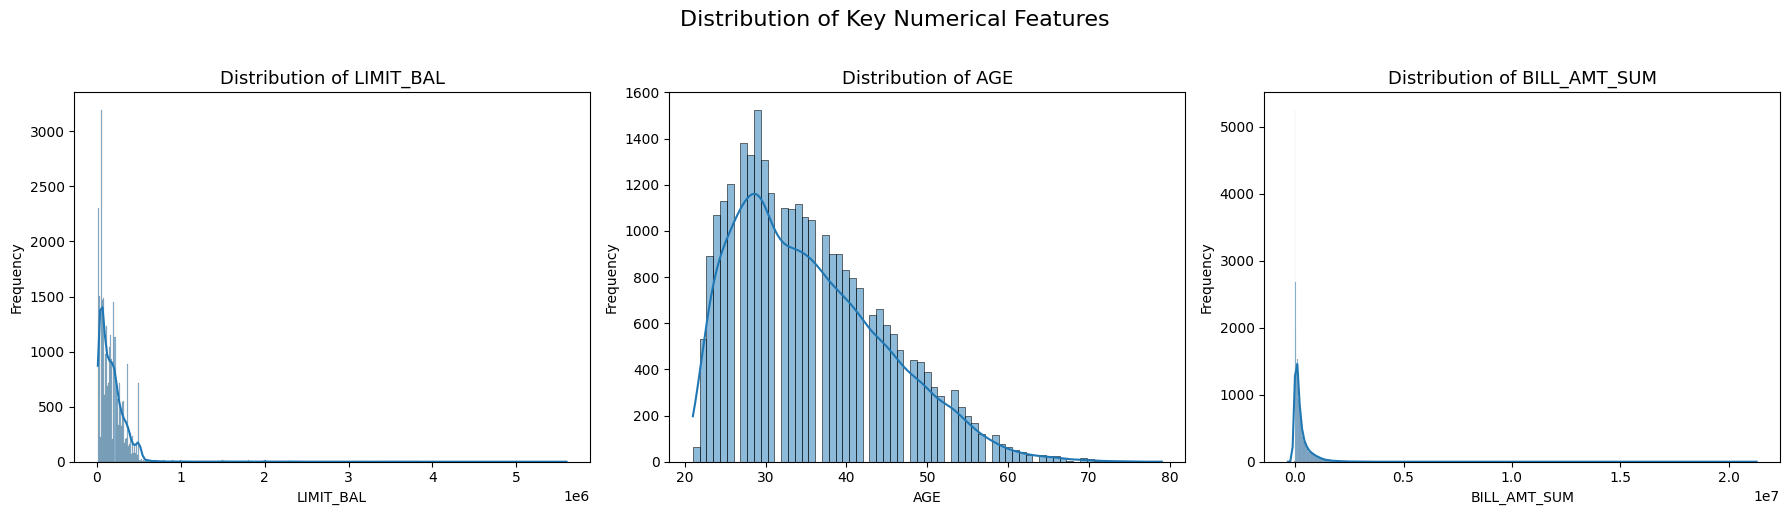

In [25]:
numerical_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numerical_features):
    
    sns.histplot(
        data=df_clean,
        x=col,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Key Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Boxplots for Numerical Features


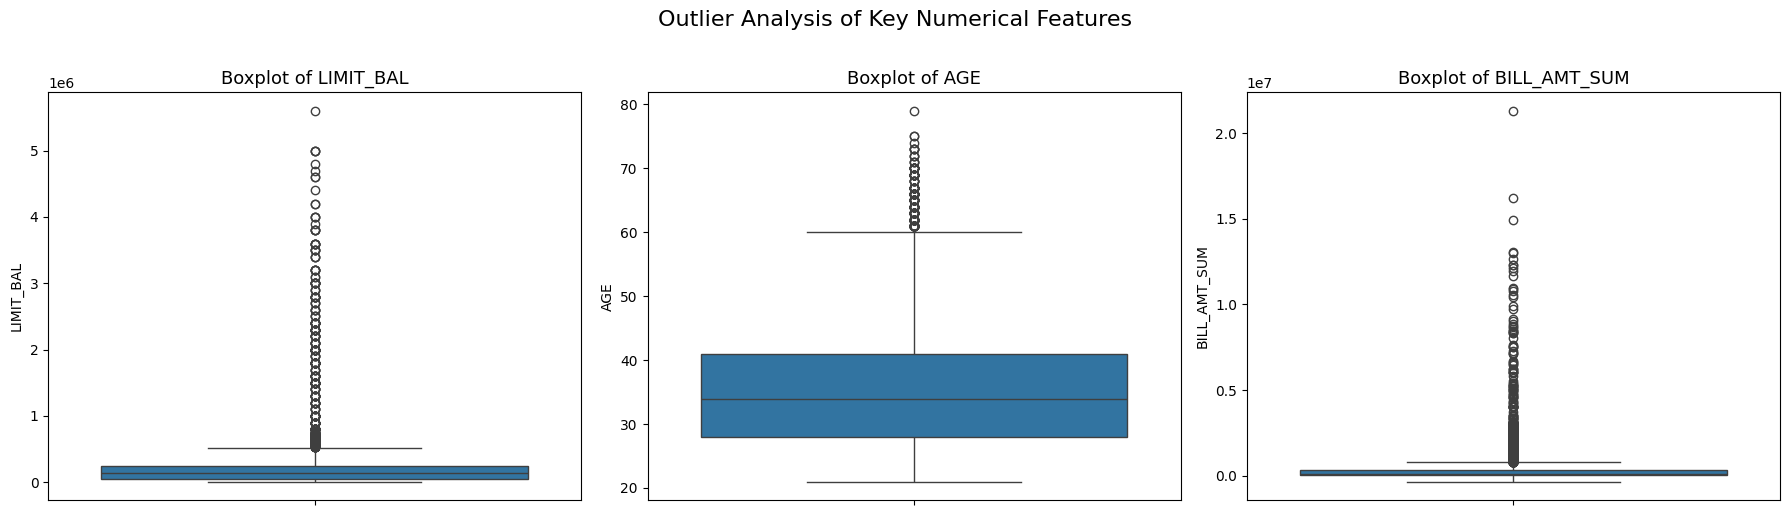

In [26]:
numerical_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numerical_features):
    
    sns.boxplot(
        data=df_clean,
        y=col,
        ax=ax
    )
    
    ax.set_title(f"Boxplot of {col}", fontsize=13)
    ax.set_ylabel(col)

plt.suptitle(
    "Outlier Analysis of Key Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


outlier_summary = []

for col in numerical_features:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(df_clean) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("\nIQR-Based Outlier Summary:")
display(outlier_summary)

### Payment Behaviour Analysis

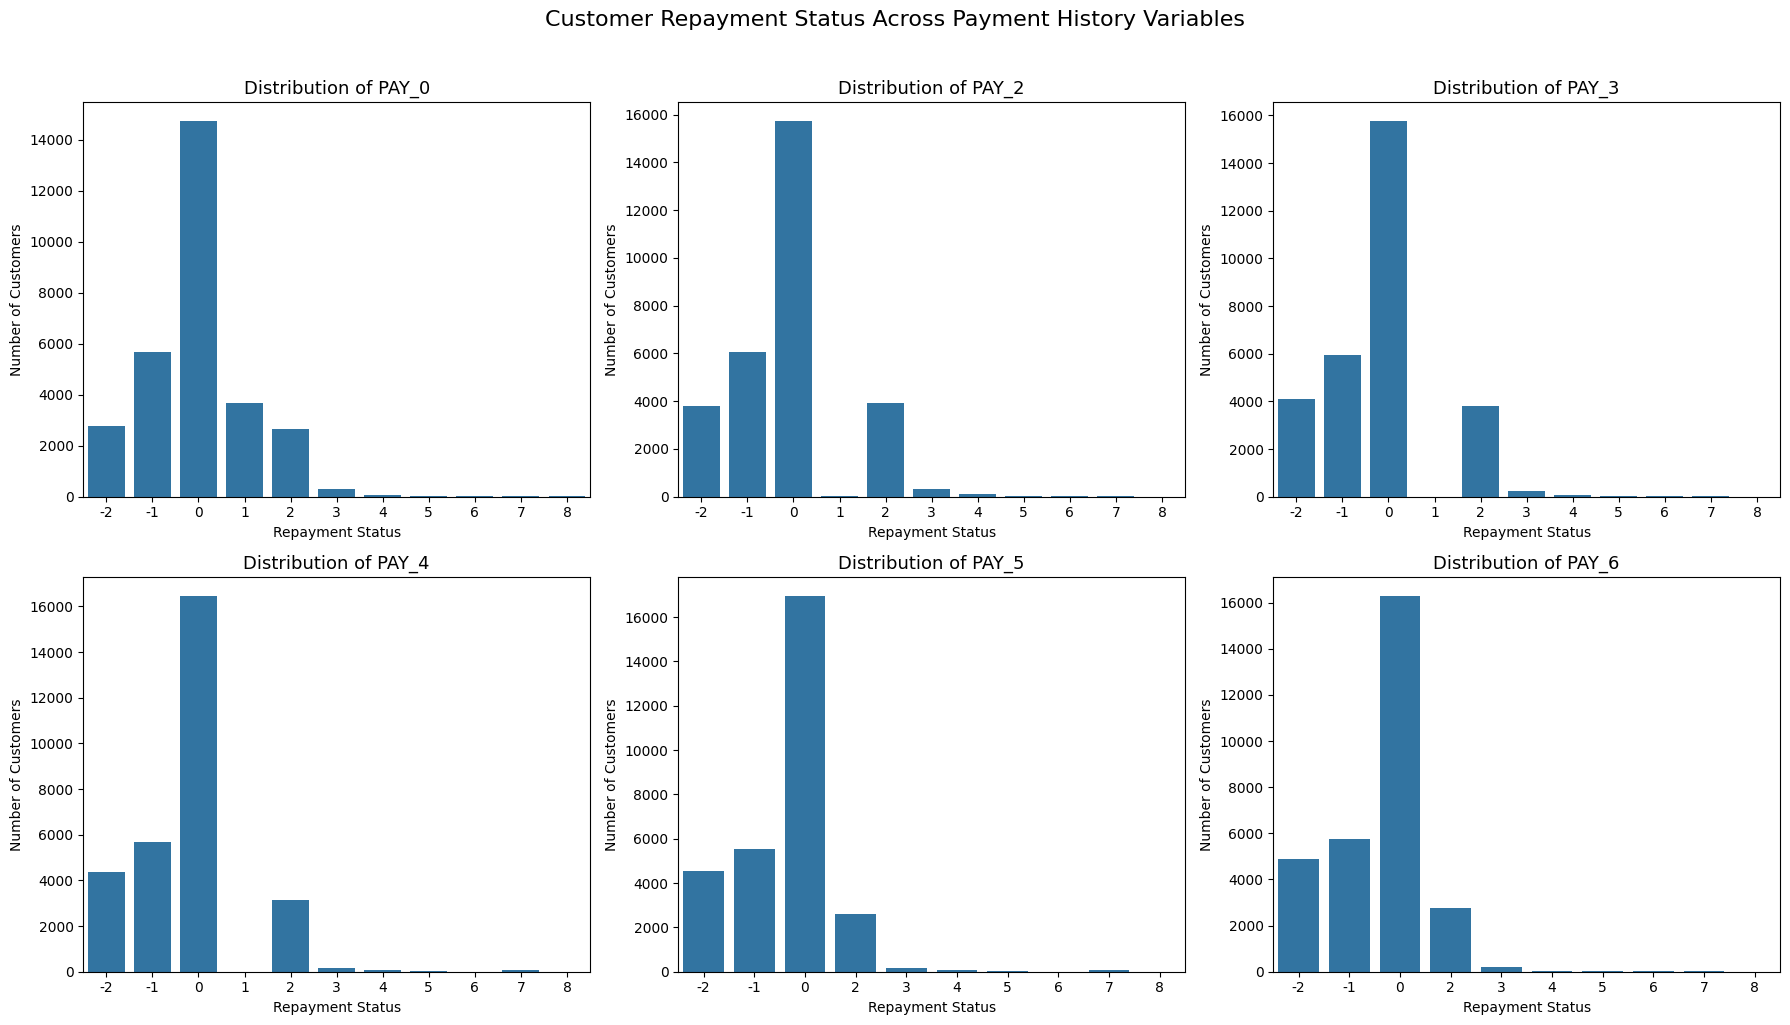

In [27]:
pay_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for ax, col in zip(axes, pay_features):
    
    order = sorted(df_clean[col].dropna().unique())
    
    sns.countplot(
        data=df_clean,
        x=col,
        order=order,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {col}", fontsize=13)
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Number of Customers")

plt.suptitle(
    "Customer Repayment Status Across Payment History Variables",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

###  Summary statistics for payment variables

In [28]:

payment_summary = df_clean[pay_features].describe().T[
    ["mean", "50%", "std", "min", "max"]
]

payment_summary.columns = [
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum"
]

payment_summary = payment_summary.round(2)

print("\nPayment Behaviour Summary:")
display(payment_summary)


Payment Behaviour Summary:


,Mean,Median,Standard Deviation,Minimum,Maximum
PAY_0,-0.02,0.0,1.12,-2.0,8.0
PAY_2,-0.13,0.0,1.20,-2.0,8.0
PAY_3,-0.17,0.0,1.20,-2.0,8.0
PAY_4,-0.22,0.0,1.17,-2.0,8.0
PAY_5,-0.27,0.0,1.13,-2.0,8.0
PAY_6,-0.29,0.0,1.15,-2.0,8.0


### Correlation Analysis with Target

In [29]:
correlation_features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT_SUM",
    "RISK_RATING",
    target
]

correlation_matrix = df_clean[correlation_features].corr()

print("Correlation of numerical features with default:")
target_correlation = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(
    target_correlation.to_frame("Correlation with Default")
)


Correlation of numerical features with default:


,Correlation with Default
RISK_RATING,0.372927
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
LIMIT_BAL,-0.095979
AGE,0.013984
BILL_AMT_SUM,-0.010681


### Heatmap

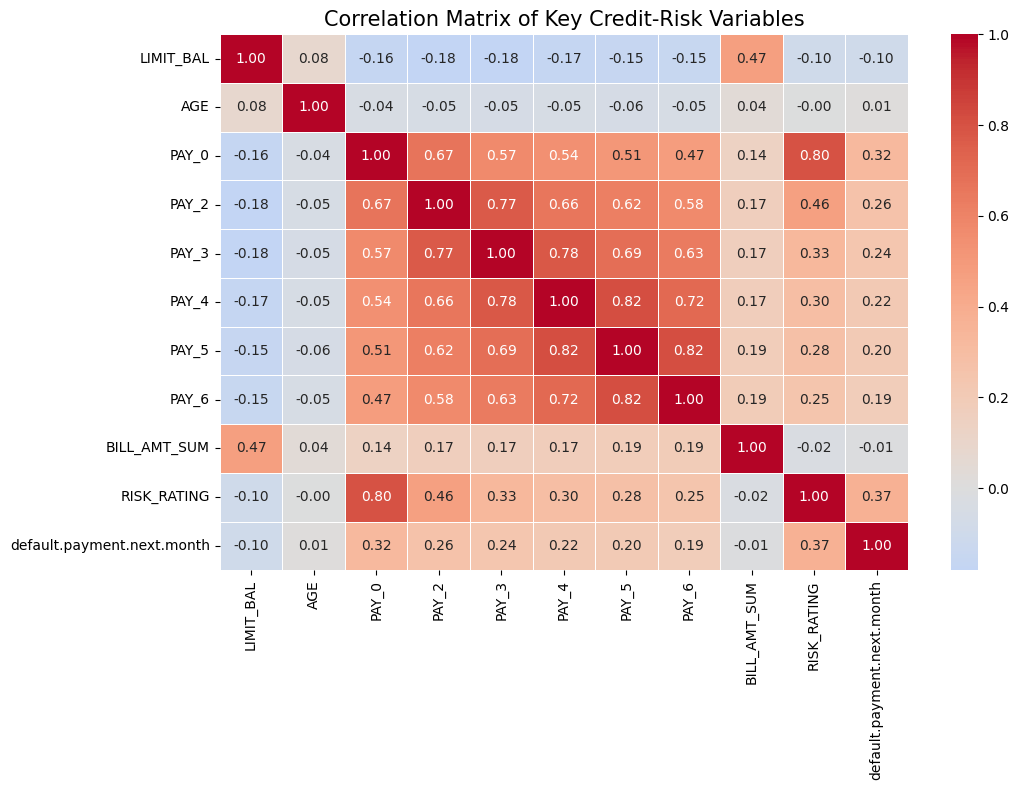

In [30]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Key Credit-Risk Variables",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Investigating risk_leak

In [31]:
print("risk_leak data type:")
print(df_clean["risk_leak"].dtype)

print("\nNumber of unique non-null values:")
print(df_clean["risk_leak"].nunique())

print("\nUnique values:")
print(df_clean["risk_leak"].dropna().unique())

print("\nValue distribution:")
risk_leak_distribution = pd.DataFrame({
    "Count": df_clean["risk_leak"].value_counts(dropna=False),
    "Percentage": (
        df_clean["risk_leak"]
        .value_counts(normalize=True, dropna=False) * 100
    ).round(2)
})

display(risk_leak_distribution)

print("\nCross-tabulation with default:")
risk_leak_target = pd.crosstab(
    df_clean["risk_leak"],
    df_clean[target],
    normalize="index"
).round(3)

display(risk_leak_target)

risk_leak data type:
object

Number of unique non-null values:
29999

Unique values:
['1.075.675.276.433.290' '10.940.840.854.872.400' '0.0703022492301175' ...
 '11.020.160.812.591.000' '0.9954254743743975' '10.837.508.567.451.100']

Value distribution:


,Count,Percentage
risk_leak,,
"-9,27E+10",2,0.01
0.015565897113188685,1,0.00
-0.04876997047423957,1,0.00
0.011800801179792673,1,0.00
-0.01258620280759224,1,0.00
...,...,...
10.975.965.043.738.200,1,0.00
0.016282272970592624,1,0.00
0.10196112558873571,1,0.00



Cross-tabulation with default:


default.payment.next.month,0,1
risk_leak,,
-0.00012166952260236988,1.0,0.0
-0.00012265370961008775,1.0,0.0
-0.00013190481733586692,1.0,0.0
-0.00013763836815564837,1.0,0.0
-0.00014433012827898904,1.0,0.0
...,...,...
"6,26E+10",1.0,0.0
"6,64E+09",1.0,0.0
"7,60E+10",1.0,0.0


### Numerical Investigation of risk_leak

In [32]:
risk_raw = df_clean["risk_leak"].astype("string").str.strip()

def convert_risk_value(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value)
    
    if value.count(".") > 1:
        parts = value.split(".")
        
        if parts[0] == "-":
            return np.nan
        
        try:
            return float(parts[0] + "".join(parts[1:]))
        except ValueError:
            return np.nan
    
    try:
        return float(value)
    except ValueError:
        return np.nan


risk_numeric = risk_raw.apply(convert_risk_value)

print("Original risk_leak values:", len(risk_raw))
print("Successfully converted:", risk_numeric.notna().sum())
print("Could not be converted:", risk_numeric.isna().sum())

print("\nBasic statistics of converted risk_leak:")
display(risk_numeric.describe().to_frame("risk_leak"))

print("\nCorrelation with default:")
risk_correlation = pd.concat(
    [
        risk_numeric.rename("risk_leak"),
        df_clean[target]
    ],
    axis=1
).corr().loc["risk_leak", target]

print(round(risk_correlation, 4))

Original risk_leak values: 30000
Successfully converted: 29974
Could not be converted: 26

Basic statistics of converted risk_leak:


,risk_leak
count,2.997400e+04
mean,9.598046e+14
std,3.038750e+15
min,-3.852082e-01
25%,-4.780679e-02
50%,3.659025e-02
75%,1.809434e-01
max,1.396316e+16



Correlation with default:
0.5923


###  risk_leak Relationship with Default

risk_leak Summary by Default Class:


,count,mean,median,std,min,max
Default,,,,,,
0,23338,-3.000000e-04,-6.000000e-04,1.010000e-01,-0.3852,4.298000e-01
1,6636,4.335320e+15,1.037814e+14,5.203613e+15,0.6440,1.396316e+16



Correlation between converted risk_leak and default: 0.5923

Missing or non-convertible risk_leak values: 26


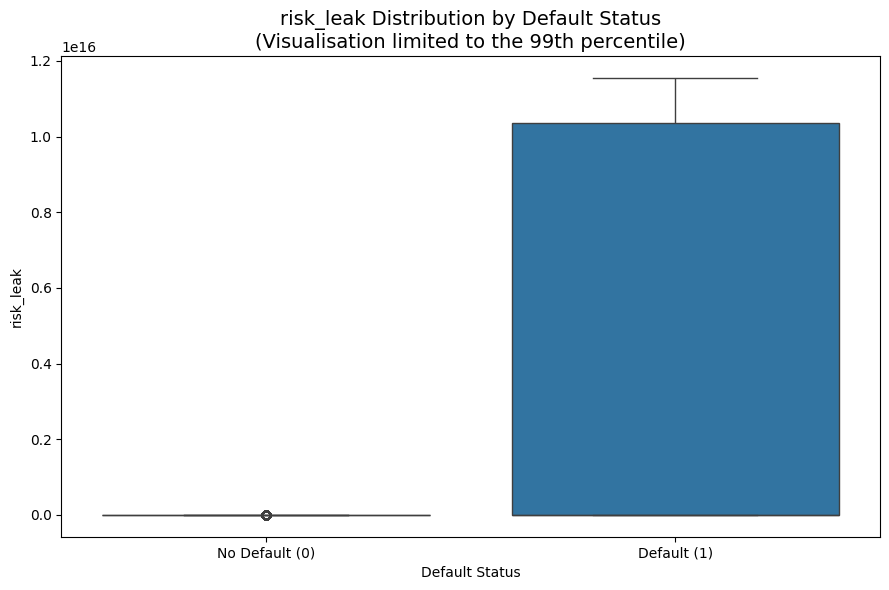

In [33]:
risk_analysis = pd.DataFrame({
    "risk_leak": risk_numeric,
    "Default": df_clean[target]
})

risk_by_default = (
    risk_analysis
    .groupby("Default")["risk_leak"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

print("risk_leak Summary by Default Class:")
display(risk_by_default)

print(
    "\nCorrelation between converted risk_leak and default:",
    round(risk_analysis["risk_leak"].corr(risk_analysis["Default"]), 4)
)

print("\nMissing or non-convertible risk_leak values:",
      risk_analysis["risk_leak"].isna().sum())

# Boxplot using a robust visual limit based on the 99th percentile
upper_visual_limit = risk_analysis["risk_leak"].quantile(0.99)

plot_data = risk_analysis[
    risk_analysis["risk_leak"] <= upper_visual_limit
].copy()

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_data,
    x="Default",
    y="risk_leak"
)

plt.title(
    "risk_leak Distribution by Default Status\n"
    "(Visualisation limited to the 99th percentile)",
    fontsize=14
)

plt.xlabel("Default Status")
plt.ylabel("risk_leak")

plt.xticks(
    [0, 1],
    ["No Default (0)", "Default (1)"]
)

plt.tight_layout()
plt.show()

### Corrected risk_leak Conversion

In [34]:
def clean_risk_leak(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    value = value.replace(",", ".")

    if value.count(".") > 1:
        first_dot = value.find(".")
        
        value = (
            value[:first_dot + 1]
            + value[first_dot + 1:].replace(".", "")
        )

    try:
        return float(value)
    except ValueError:
        return np.nan


risk_numeric_corrected = (
    df_clean["risk_leak"]
    .apply(clean_risk_leak)
)

print("Original risk_leak values:", len(df_clean))

print(
    "Successfully converted:",
    risk_numeric_corrected.notna().sum()
)

print(
    "Could not be converted:",
    risk_numeric_corrected.isna().sum()
)

print("\nCorrected descriptive statistics:")
display(
    risk_numeric_corrected.describe()
    .to_frame("risk_leak")
)

corrected_correlation = pd.concat(
    [
        risk_numeric_corrected.rename("risk_leak"),
        df_clean[target]
    ],
    axis=1
).corr().loc["risk_leak", target]

print(
    "\nCorrected correlation with default:",
    round(corrected_correlation, 4)
)

Original risk_leak values: 30000
Successfully converted: 30000
Could not be converted: 0

Corrected descriptive statistics:


,risk_leak
count,3.000000e+04
mean,-5.555033e+07
std,5.422580e+09
min,-5.350000e+11
25%,-4.794720e-02
50%,3.653958e-02
75%,1.809670e-01
max,4.120000e+11



Corrected correlation with default: 0.0055


### Default Rate by Risk Rating

Default Rate by Risk Rating:


,count,sum,Default Rate (%)
RISK_RATING,,,
1,23182,3207,13.83
2,6355,3096,48.72
3,463,333,71.92


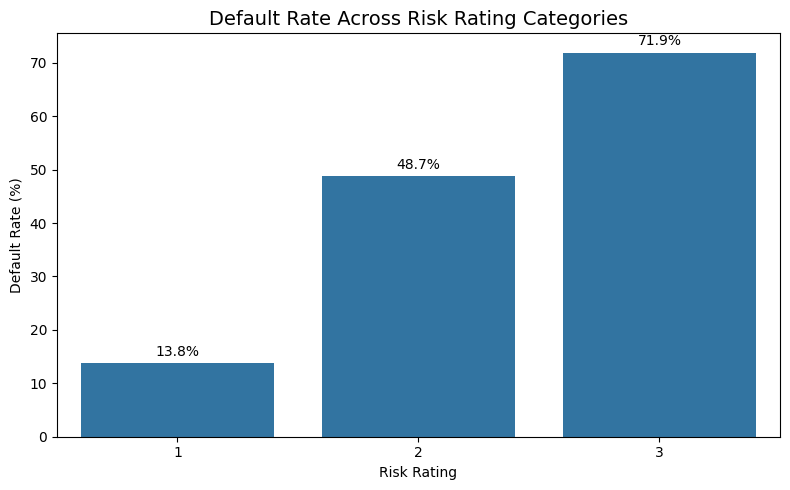

In [35]:
risk_rating_default = (
    df_clean
    .groupby("RISK_RATING")[target]
    .agg(["count", "sum", "mean"])
)

risk_rating_default["Default Rate (%)"] = (
    risk_rating_default["mean"] * 100
).round(2)

risk_rating_default = risk_rating_default.drop(columns=["mean"])

print("Default Rate by Risk Rating:")
display(risk_rating_default)

# Visualisation
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=risk_rating_default.reset_index(),
    x="RISK_RATING",
    y="Default Rate (%)"
)

plt.title(
    "Default Rate Across Risk Rating Categories",
    fontsize=14
)

plt.xlabel("Risk Rating")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### Default Rate by Most Recent Payment Status


Default Rate by PAY_0:


,count,sum,Default Rate (%)
PAY_0,,,
-2,2759,365,13.23
-1,5686,954,16.78
0,14737,1888,12.81
1,3688,1252,33.95
2,2667,1844,69.14
3,322,244,75.78
4,76,52,68.42
5,26,13,50.00
6,11,6,54.55


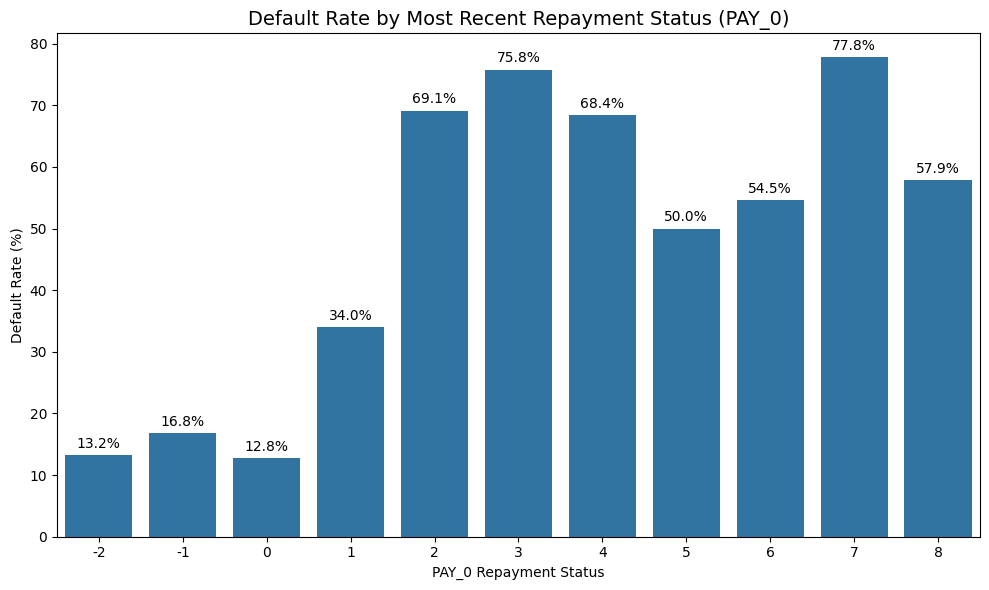

In [75]:
pay0_default = (
    df_clean
    .groupby("PAY_0")[target]
    .agg(["count", "sum", "mean"])
)

pay0_default["Default Rate (%)"] = (
    pay0_default["mean"] * 100
).round(2)

pay0_default = pay0_default.drop(columns=["mean"])

print("Default Rate by PAY_0:")
display(pay0_default)


plot_pay0 = pay0_default.reset_index()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_pay0,
    x="PAY_0",
    y="Default Rate (%)"
)

plt.title(
    "Default Rate by Most Recent Repayment Status (PAY_0)",
    fontsize=14
)

plt.xlabel("PAY_0 Repayment Status")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

### Initial Data Preparation

### Create a separate modelling dataset

In [36]:
model_df = df_clean.copy()

columns_to_remove = [
    "ID",
    "LIMIT_BAL_LOG",
    "risk_leak"
]

model_df = model_df.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("Original cleaned dataset shape:")
print(df_clean.shape)

print("\nModelling dataset shape:")
print(model_df.shape)

print("\nRemoved columns:")
print(columns_to_remove)

print("\nRemaining columns:")
print(model_df.columns.tolist())

print("\nMissing values remaining:")
remaining_missing = model_df.isnull().sum()
display(
    remaining_missing[remaining_missing > 0]
    .to_frame("Missing Count")
)

Original cleaned dataset shape:
(30000, 30)

Modelling dataset shape:
(30000, 27)

Removed columns:
['ID', 'LIMIT_BAL_LOG', 'risk_leak']

Remaining columns:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'BILL_AMT_SUM', 'CITY', 'RISK_RATING']

Missing values remaining:


,Missing Count
LIMIT_BAL,1500
SEX,1500
EDUCATION,1500
MARRIAGE,1500
AGE,1500
PAY_AMT1,1500
PAY_AMT2,1500


###  Define Target, Numerical and Categorical Features

In [37]:

target = "default.payment.next.month"

# Separate target variable
X = model_df.drop(columns=[target])
y = model_df[target]


In [38]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]



In [39]:
numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [40]:
print("Target variable:")
print(target)

print("\nNumber of observations:", len(X))
print("Number of predictor variables:", X.shape[1])

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nTarget distribution:")
target_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

display(target_distribution)

Target variable:
default.payment.next.month

Number of observations: 30000
Number of predictor variables: 26

Numerical features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT_SUM']

Number of numerical features: 21

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE', 'CITY', 'RISK_RATING']

Number of categorical features: 5

Target distribution:


,Count,Percentage
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


### Stratified Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set shape:")
print(X_train.shape)

print("\nTesting set shape:")
print(X_test.shape)

print("\nTraining target distribution:")
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})
display(train_distribution)

print("\nTesting target distribution:")
test_distribution = pd.DataFrame({
    "Count": y_test.value_counts().sort_index(),
    "Percentage": (
        y_test.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})
display(test_distribution)

Training set shape:
(24000, 26)

Testing set shape:
(6000, 26)

Training target distribution:


,Count,Percentage
default.payment.next.month,,
0,18691,77.88
1,5309,22.12



Testing target distribution:


,Count,Percentage
default.payment.next.month,,
0,4673,77.88
1,1327,22.12


### Leakage-Safe Preprocessing Pipeline

### Numerical preprocessing:

In [42]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)



### Categorical preprocessing:

In [43]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

### Combine both preprocessing strategies


In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

print("\nNumerical preprocessing:")
print("1. Median imputation")
print("2. Standard scaling")

print("\nCategorical preprocessing:")
print("1. Most-frequent imputation")
print("2. One-hot encoding")
print("3. Unknown categories ignored during testing")

print("\nPreprocessing will be fitted only on the training data.")

Preprocessing pipeline created successfully.

Numerical preprocessing:
1. Median imputation
2. Standard scaling

Categorical preprocessing:
1. Most-frequent imputation
2. One-hot encoding
3. Unknown categories ignored during testing

Preprocessing will be fitted only on the training data.


### Verify Preprocessing Transformation

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training feature shape:")
print(X_train.shape)

print("\nOriginal testing feature shape:")
print(X_test.shape)

print("\nProcessed training feature shape:")
print(X_train_processed.shape)

print("\nProcessed testing feature shape:")
print(X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Training:", np.isnan(X_train_processed).sum())
print("Testing :", np.isnan(X_test_processed).sum())

print("\nPreprocessing verification completed successfully.")

Original training feature shape:
(24000, 26)

Original testing feature shape:
(6000, 26)

Processed training feature shape:
(24000, 87)

Processed testing feature shape:
(6000, 87)

Missing values after preprocessing:
Training: 0
Testing : 0

Preprocessing verification completed successfully.


### Define  Machine-Learning Models

In [46]:
models = {
    "Logistic Regression": LogisticRegression(),
    
    "Support Vector Machine": SVC(),
    
    "K-Nearest Neighbours": KNeighborsClassifier(),
    
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

print("models created successfully.\n")


models created successfully.



###  Leakage-Safe Model Pipelines

In [47]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.\n")


Model pipelines created successfully.



### Train  Models

In [48]:
trained_models = {}

for name, pipeline in model_pipelines.items():
    print(f"Training {name}...")
    
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    print(f"{name} completed.\n")

print("All models have been trained.")

Training Logistic Regression...
Logistic Regression completed.

Training Support Vector Machine...
Support Vector Machine completed.

Training K-Nearest Neighbours...
K-Nearest Neighbours completed.

Training Random Forest...
Random Forest completed.

Training Gradient Boosting...
Gradient Boosting completed.

All models have been trained.


### Predictions and Scores

In [49]:
predictions = {}
prediction_scores = {}

for name, model in trained_models.items():
    
    print(f"Generating predictions for {name}...")
    
    # Class predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Score used for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    prediction_scores[name] = y_score

print("\nPredictions generated successfully for all five models.")

print("\nPrediction shapes:")
for name in predictions:
    print(f"{name}: {predictions[name].shape}")

Generating predictions for Logistic Regression...
Generating predictions for Support Vector Machine...
Generating predictions for K-Nearest Neighbours...
Generating predictions for Random Forest...
Generating predictions for Gradient Boosting...

Predictions generated successfully for all five models.

Prediction shapes:
Logistic Regression: (6000,)
Support Vector Machine: (6000,)
K-Nearest Neighbours: (6000,)
Random Forest: (6000,)
Gradient Boosting: (6000,)


### Model Performance Comparison

In [50]:
results = []

for name in trained_models:
    
    y_pred = predictions[name]
    y_score = prediction_scores[name]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results)

results_df_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_df_display[metric_columns] = (
    results_df_display[metric_columns] * 100
).round(2)

print("Baseline Model Performance:")
display(results_df_display)

Baseline Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.02,58.79,32.25,41.65,72.60
1,Support Vector Machine,81.85,67.81,34.14,45.41,71.35
2,K-Nearest Neighbours,79.80,56.82,36.10,44.15,70.71
3,Random Forest,81.35,63.98,35.87,45.97,75.97
4,Gradient Boosting,81.80,65.99,36.55,47.04,77.59


### Visual Comparison of Baseline Models

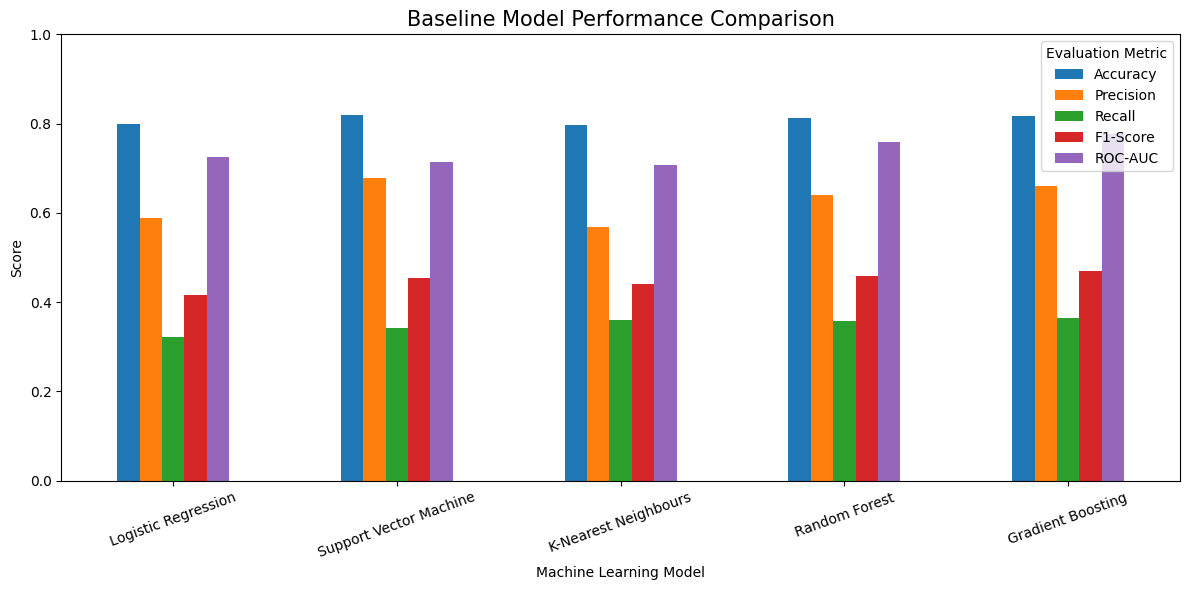

In [51]:
plot_results = results_df.copy()

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_results = plot_results.set_index("Model")[metrics_to_plot]

plot_results.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison", fontsize=15)
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

### Confusion Matrices 

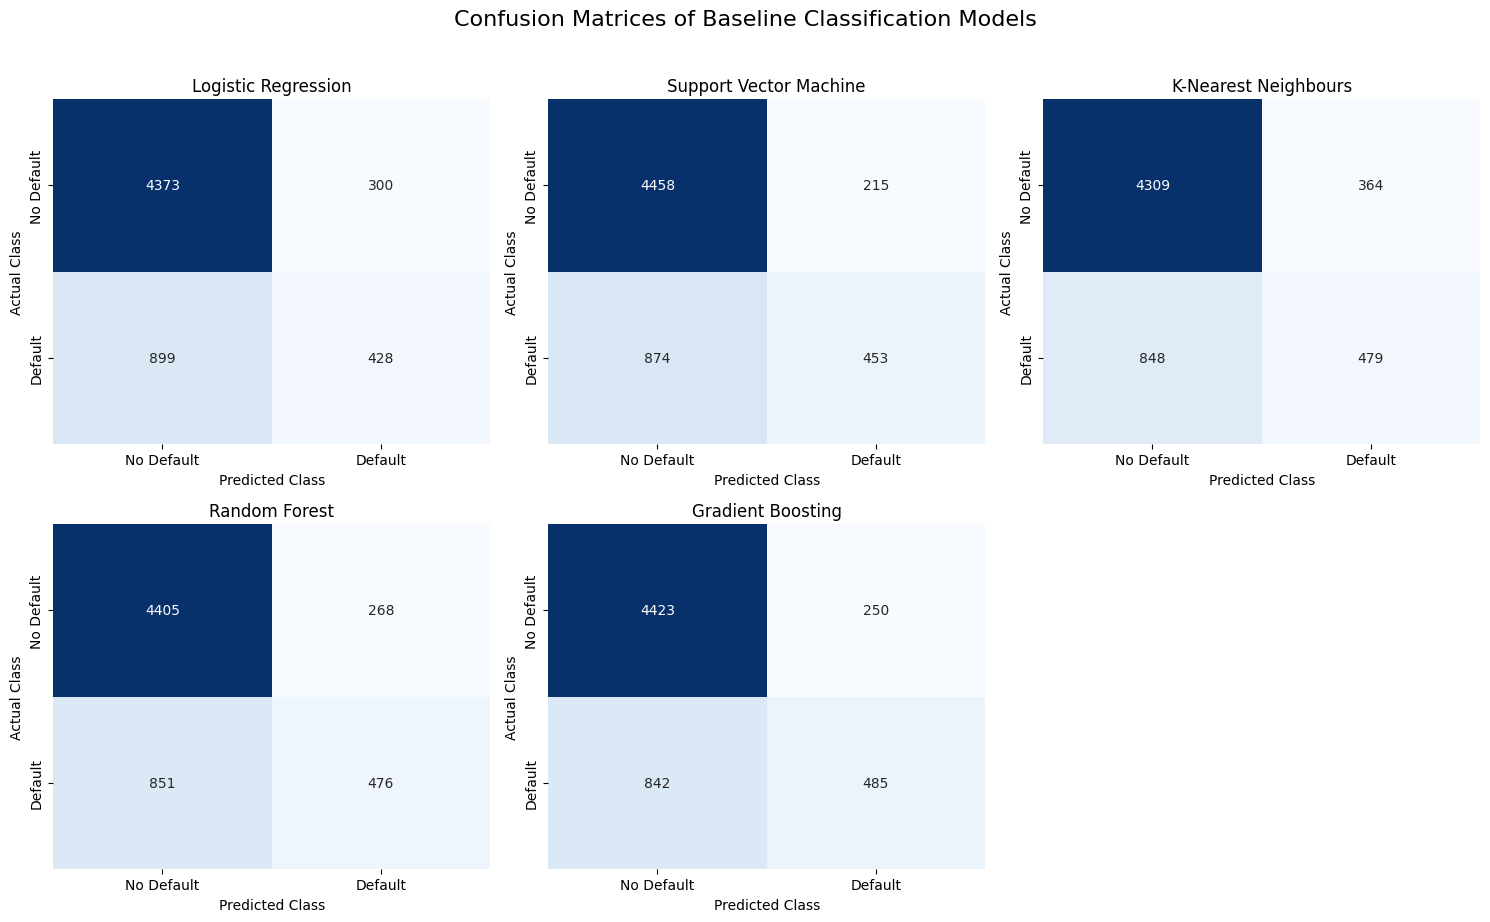

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )
    
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")
    axes[i].set_xticklabels(["No Default", "Default"])
    axes[i].set_yticklabels(["No Default", "Default"])

fig.delaxes(axes[5])

plt.suptitle(
    "Confusion Matrices of Baseline Classification Models",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### ROC Curves

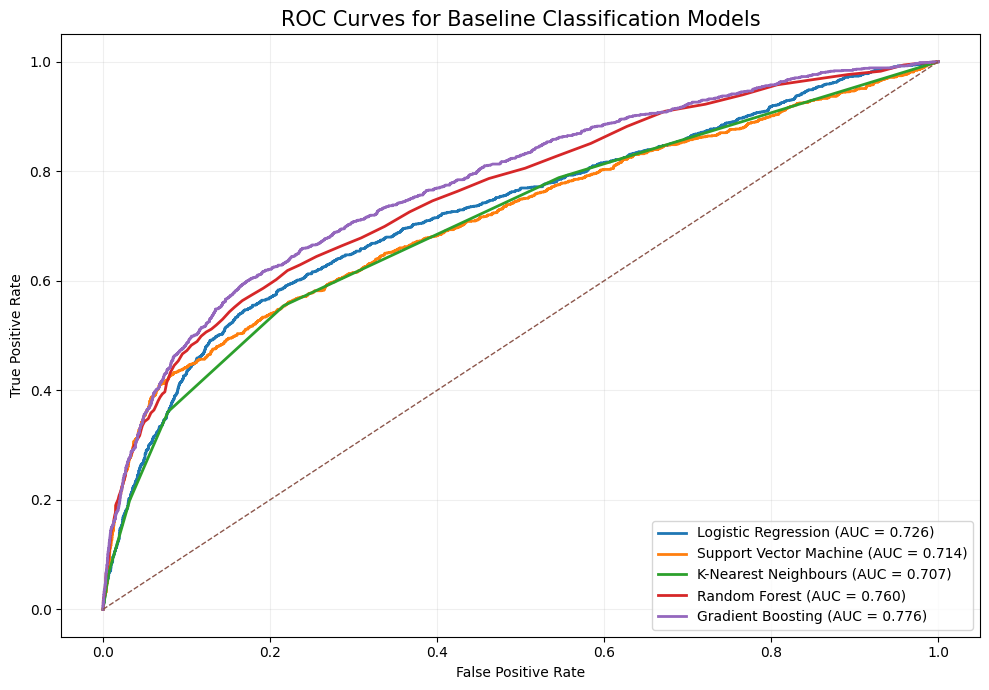

In [53]:
plt.figure(figsize=(10, 7))

for name, y_score in prediction_scores.items():
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_value:.3f})"
    )

# Reference line for random classification
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Classification Models", fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

###  Detailed Classification Reports

In [57]:
for name, y_pred in predictions.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Default", "Default"],
            digits=3
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  No Default      0.829     0.936     0.879      4673
     Default      0.588     0.323     0.417      1327

    accuracy                          0.800      6000
   macro avg      0.709     0.629     0.648      6000
weighted avg      0.776     0.800     0.777      6000

Support Vector Machine
              precision    recall  f1-score   support

  No Default      0.836     0.954     0.891      4673
     Default      0.678     0.341     0.454      1327

    accuracy                          0.819      6000
   macro avg      0.757     0.648     0.673      6000
weighted avg      0.801     0.819     0.795      6000

K-Nearest Neighbours
              precision    recall  f1-score   support

  No Default      0.836     0.922     0.877      4673
     Default      0.568     0.361     0.441      1327

    accuracy                          0.798      6000
   macro avg      0.702     0.642     0.659      6000
weighted a

### Select Best  Model for Tuning

In [58]:
best_baseline = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("Best baseline model based on F1-score:")
print(best_baseline)

print("\nModel selected for hyperparameter tuning:")
print(best_baseline["Model"])

Best baseline model based on F1-score:
Model        Gradient Boosting
Accuracy                 0.818
Precision             0.659864
Recall                0.365486
F1-Score              0.470417
ROC-AUC               0.775906
Name: 4, dtype: object

Model selected for hyperparameter tuning:
Gradient Boosting


### Gradient Boosting Hyperparameter Tuning

In [59]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("Starting Gradient Boosting hyperparameter tuning...")

gb_grid.fit(X_train, y_train)

print("\nTuning completed.")
print("Best parameters:")
print(gb_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(gb_grid.best_score_, 4))

Starting Gradient Boosting hyperparameter tuning...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Tuning completed.
Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best cross-validation ROC-AUC:
0.7797


### Evaluate Tuned Gradient Boosting on Test Data

In [61]:
tuned_gb = gb_grid.best_estimator_

tuned_gb_pred = tuned_gb.predict(X_test)
tuned_gb_score = tuned_gb.predict_proba(X_test)[:, 1]

tuned_gb_results = {
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(y_test, tuned_gb_pred),
    "Precision": precision_score(y_test, tuned_gb_pred),
    "Recall": recall_score(y_test, tuned_gb_pred),
    "F1-Score": f1_score(y_test, tuned_gb_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_gb_score)
}

print("Tuned Gradient Boosting Test Performance:")
print()

for metric, value in tuned_gb_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.4f} ({value * 100:.2f}%)")

Tuned Gradient Boosting Test Performance:

Accuracy: 0.8180 (81.80%)
Precision: 0.6648 (66.48%)
Recall: 0.3572 (35.72%)
F1-Score: 0.4647 (46.47%)
ROC-AUC: 0.7748 (77.48%)


### Baseline vs Tuned Gradient Boosting

In [63]:
baseline_gb = results_df[
    results_df["Model"] == "Gradient Boosting"
].iloc[0]

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline Gradient Boosting": [
        baseline_gb["Accuracy"],
        baseline_gb["Precision"],
        baseline_gb["Recall"],
        baseline_gb["F1-Score"],
        baseline_gb["ROC-AUC"]
    ],
    "Tuned Gradient Boosting": [
        tuned_gb_results["Accuracy"],
        tuned_gb_results["Precision"],
        tuned_gb_results["Recall"],
        tuned_gb_results["F1-Score"],
        tuned_gb_results["ROC-AUC"]
    ]
})

comparison_display = comparison.copy()

comparison_display[
    ["Baseline Gradient Boosting", "Tuned Gradient Boosting"]
] = (
    comparison_display[
        ["Baseline Gradient Boosting", "Tuned Gradient Boosting"]
    ] * 100
).round(2)

display(comparison_display)

,Metric,Baseline Gradient Boosting,Tuned Gradient Boosting
0,Accuracy,81.80,81.80
1,Precision,65.99,66.48
2,Recall,36.55,35.72
3,F1-Score,47.04,46.47
4,ROC-AUC,77.59,77.48


###  Before vs After Tuning Performance

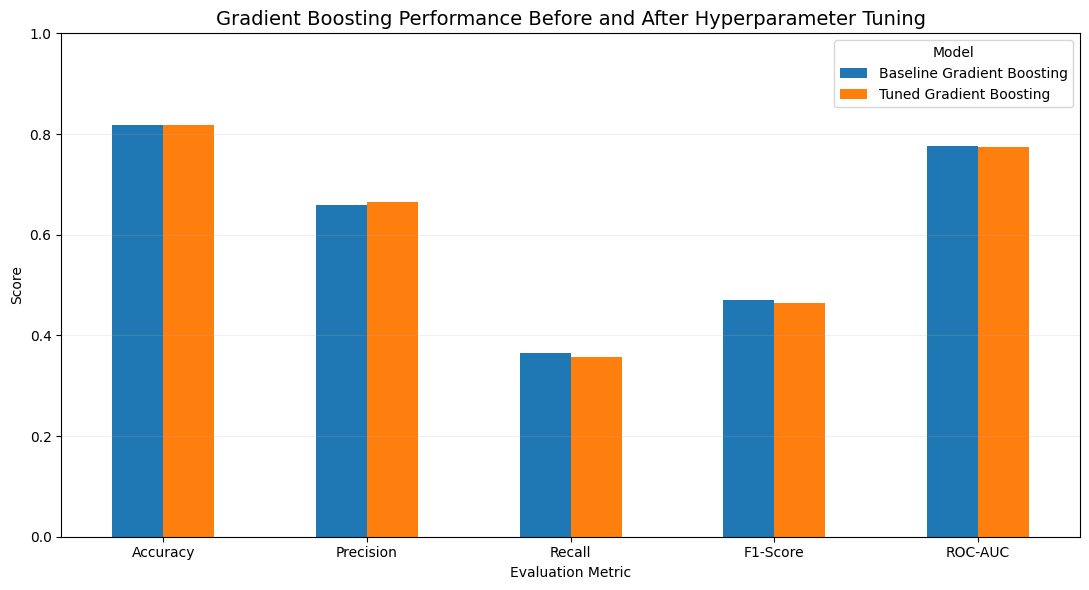

In [64]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Gradient Boosting Performance Before and After Hyperparameter Tuning",
    fontsize=14
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### Permutation Feature Importance

In [65]:
print("Calculating permutation feature importance...")

perm_result = permutation_importance(
    tuned_gb,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\nTop 15 features:")
display(feature_importance.head(15))

Calculating permutation feature importance...

Top 15 features:


,Feature,Importance,Std
0,PAY_0,0.065144,0.002519
1,LIMIT_BAL,0.012715,0.002678
2,PAY_2,0.007502,0.001275
3,BILL_AMT_SUM,0.007268,0.001147
4,BILL_AMT1,0.006543,0.001852
5,PAY_3,0.005449,0.001371
6,PAY_AMT2,0.003169,0.000301
7,PAY_4,0.002983,0.001338
8,PAY_5,0.002876,0.001951
9,BILL_AMT2,0.001801,0.000640


### Top 15 Feature Importance Visualisation

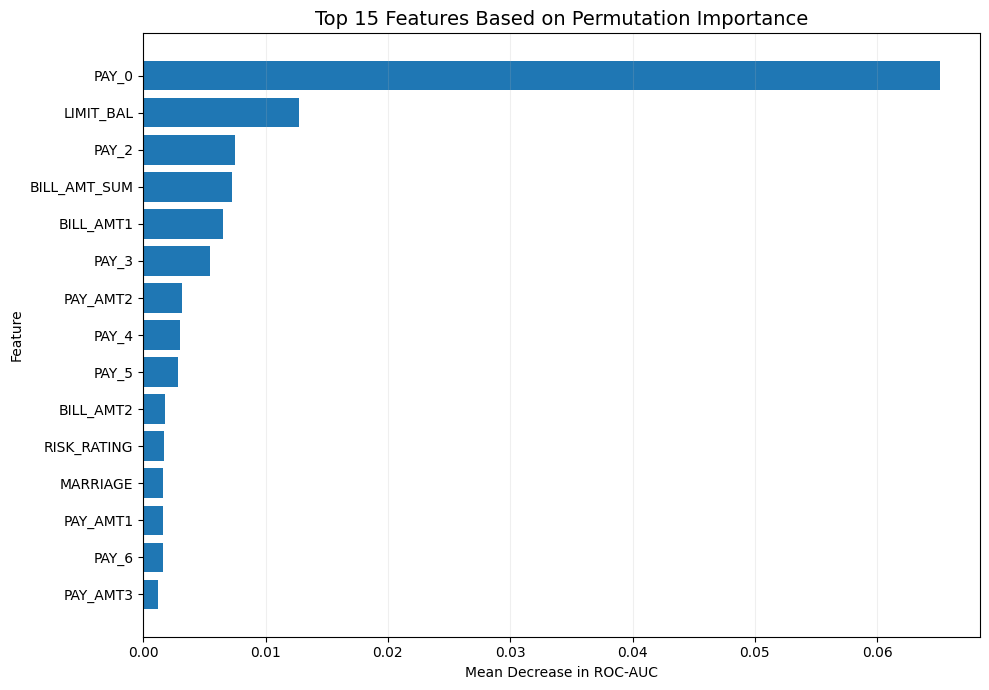

In [66]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Based on Permutation Importance",
    fontsize=14
)

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Confusion Matrix for Tuned Gradient Boosting

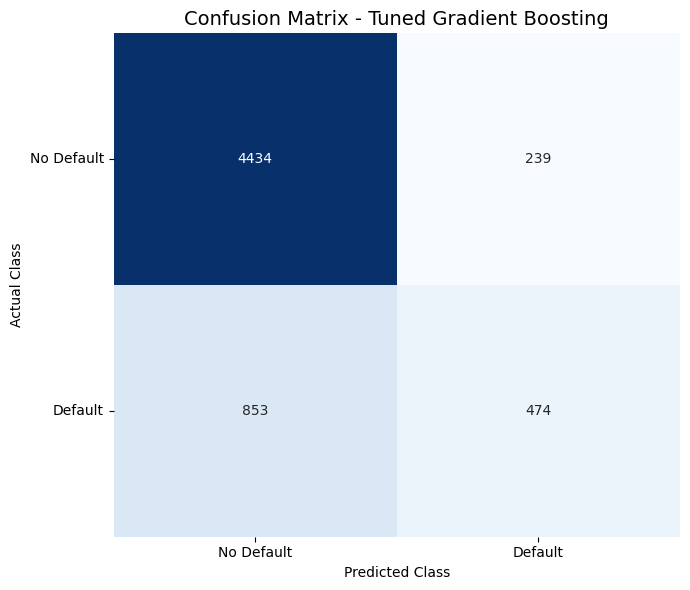

In [68]:
cm_tuned = confusion_matrix(y_test, tuned_gb_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - Tuned Gradient Boosting", fontsize=14)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0.5, 1.5],
    ["No Default", "Default"]
)

plt.yticks(
    [0.5, 1.5],
    ["No Default", "Default"],
    rotation=0
)

plt.tight_layout()
plt.show()

### ROC Curve for Tuned Gradient Boosting

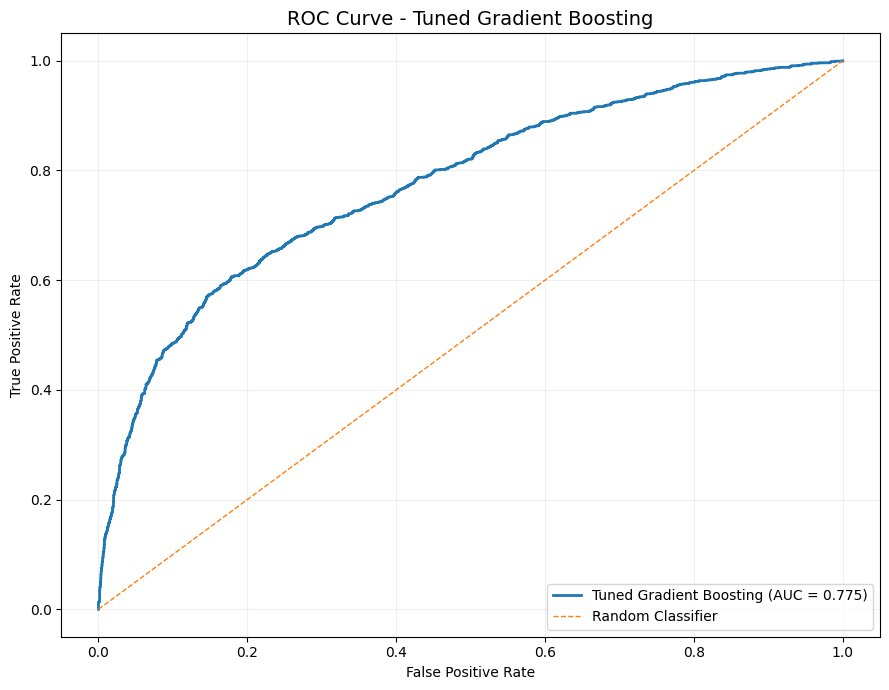

In [69]:
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test,
    tuned_gb_score
)

auc_tuned = roc_auc_score(
    y_test,
    tuned_gb_score
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_tuned,
    tpr_tuned,
    linewidth=2,
    label=f"Tuned Gradient Boosting (AUC = {auc_tuned:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curve - Tuned Gradient Boosting",
    fontsize=14
)

plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Final Model Comparison

In [70]:
final_results = results_df.copy()

tuned_row = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "Accuracy": tuned_gb_results["Accuracy"],
    "Precision": tuned_gb_results["Precision"],
    "Recall": tuned_gb_results["Recall"],
    "F1-Score": tuned_gb_results["F1-Score"],
    "ROC-AUC": tuned_gb_results["ROC-AUC"]
}])

final_results = pd.concat(
    [final_results, tuned_row],
    ignore_index=True
)

final_results_display = final_results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_results_display[metric_columns] = (
    final_results_display[metric_columns] * 100
).round(2)

display(final_results_display)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.02,58.79,32.25,41.65,72.60
1,Support Vector Machine,81.85,67.81,34.14,45.41,71.35
2,K-Nearest Neighbours,79.80,56.82,36.10,44.15,70.71
3,Random Forest,81.35,63.98,35.87,45.97,75.97
4,Gradient Boosting,81.80,65.99,36.55,47.04,77.59
5,Tuned Gradient Boosting,81.80,66.48,35.72,46.47,77.48


###  Fairness Analysis by Sex

In [71]:
fairness_data = X_test[["SEX"]].copy()
fairness_data["Actual"] = y_test.values
fairness_data["Predicted"] = tuned_gb_pred

fairness_data["SEX"] = fairness_data["SEX"].fillna("Missing")

fairness_results = []

for group in fairness_data["SEX"].unique():

    group_data = fairness_data[
        fairness_data["SEX"] == group
    ]

    actual = group_data["Actual"]
    predicted = group_data["Predicted"]

    tn, fp, fn, tp = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1]
    ).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    fairness_results.append({
        "SEX Group": group,
        "Sample Size": len(group_data),
        "Default Recall": recall,
        "False Positive Rate": fpr
    })

fairness_df = pd.DataFrame(fairness_results)

fairness_df[
    ["Default Recall", "False Positive Rate"]
] = (
    fairness_df[
        ["Default Recall", "False Positive Rate"]
    ] * 100
).round(2)

display(fairness_df)

,SEX Group,Sample Size,Default Recall,False Positive Rate
0,1.0,2279,36.07,5.91
1,2.0,3412,36.04,4.90
2,Missing,309,27.78,1.96


### Final Model Performance Comparison

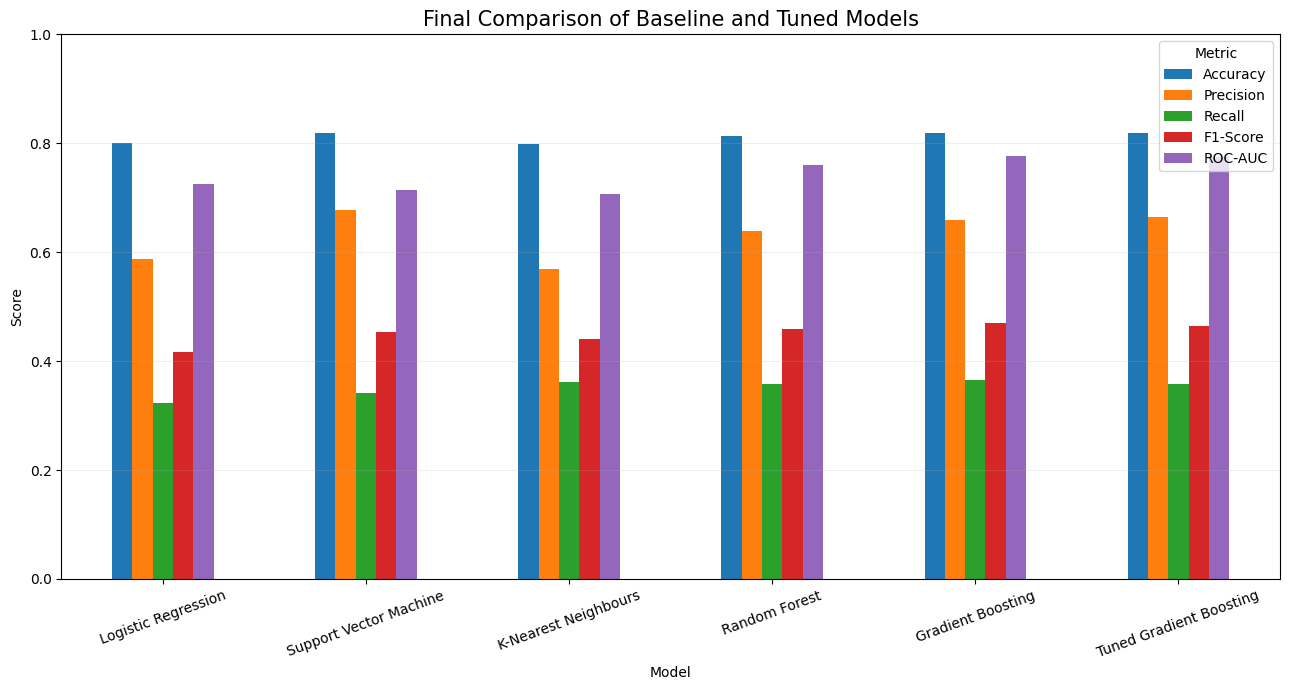

In [72]:
final_plot = final_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

final_plot.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title(
    "Final Comparison of Baseline and Tuned Models",
    fontsize=15
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### Final Results Summary

In [73]:
final_summary = final_results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_summary[metric_columns] = (
    final_summary[metric_columns] * 100
).round(2)

print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(final_summary)

print("\nBaseline Gradient Boosting:")
print(
    f"F1-Score = {baseline_gb['F1-Score'] * 100:.2f}% | "
    f"ROC-AUC = {baseline_gb['ROC-AUC'] * 100:.2f}%"
)

print("\nTuned Gradient Boosting:")
print(
    f"F1-Score = {tuned_gb_results['F1-Score'] * 100:.2f}% | "
    f"ROC-AUC = {tuned_gb_results['ROC-AUC'] * 100:.2f}%"
)

FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.02,58.79,32.25,41.65,72.60
1,Support Vector Machine,81.85,67.81,34.14,45.41,71.35
2,K-Nearest Neighbours,79.80,56.82,36.10,44.15,70.71
3,Random Forest,81.35,63.98,35.87,45.97,75.97
4,Gradient Boosting,81.80,65.99,36.55,47.04,77.59
5,Tuned Gradient Boosting,81.80,66.48,35.72,46.47,77.48



Baseline Gradient Boosting:
F1-Score = 47.04% | ROC-AUC = 77.59%

Tuned Gradient Boosting:
F1-Score = 46.47% | ROC-AUC = 77.48%
